# Module 5 — LAB (ADVANCED): Customer Segmentation, End-to-End
### Unsupervised Learning · Level: strong mid-level → senior · ~6–9 hours

A rigorous, open-ended segmentation project on **1.07M real transactions**. You design and write the
whole pipeline. This brief specifies **what** is required and **how it will be judged** — not the code.

> This is harder than a standard clustering exercise: you must engineer features beyond RFM, **compare
> multiple algorithms**, **validate with multiple metrics**, **prove your clusters are stable**, detect
> anomalies, and deliver a **quantified business report**. 'It ran' is not 'it's done.'

## 🏬 Scenario

You are the data scientist for a **UK online gift retailer**. Leadership is about to spend a large
marketing budget and wants it spent **per customer-type, not blanket**.

> CMO: *"Give me a customer segmentation I can trust and act on. I want to know who my best customers
> are, who's about to leave, and who's not worth chasing — with **numbers**, not vibes. Show me the
> segments are **real and stable**, not an artifact of one lucky run. And flag any **weird accounts** —
> we suspect some 'customers' are actually wholesalers or data errors."*

There are **no labels**. You must discover structure from behaviour, prove it holds up, and translate it
into money and actions.

## 📐 Engineering standards (graded)

This is a senior-grade deliverable. Hold yourself to:

1. **Reproducible** — fixed `random_state` everywhere; the notebook runs top-to-bottom with no manual steps.
2. **Documented decisions** — every non-obvious choice (which K, which algorithm, how you handled outliers)
   gets a 1–2 sentence justification in a markdown cell. Undocumented magic numbers lose points.
3. **No data leakage** — fit scalers/PCA on the data you cluster; never let raw Monetary scale dominate.
4. **DRY** — wrap repeated work (e.g. 'fit + score a clusterer') in a **function**, don't copy-paste.
5. **Honest** — if a metric disagrees with your choice, **say so** and explain why you chose anyway.

## ⚠️ AI-use policy & academic integrity (read carefully)

This lab is graded on **your understanding**, not on producing code an AI could write in 10 seconds.

- You may use AI to **explain concepts** and **debug your own code**.
- You may **NOT** paste these instructions into an AI and submit its output. That is plagiarism.
- **Every submission is personalised** (see the next cell): your seed and your data slice come from your
  student ID, so your numbers and segments are **unique to you**. A copied or generic AI answer will not
  match your required outputs — and the grader recomputes them from your ID.
- **You will defend your work live:** in a 5-minute viva you must explain *any* cell your instructor points
  to, justify your K, your algorithm choice, and your segment names — **without notes or AI**. If you can't
  explain it, it doesn't count, even if the code is correct.

> The fastest way to pass is to **actually do it**. Faking it fails the viva.

## 📦 Dataset

**Online Retail II (UCI)** — ~**1,067,371** transactions, UK online gift shop, Dec 2009 – Dec 2011.
Columns: `Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country`.

- `Invoice` starting with **C** = cancellation. `Quantity < 0` = a return. Many rows have **no Customer ID**.
- Loads from a URL (~95 MB, first load ~1 min).

## Setup (given)

In [18]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
RANDOM_STATE = 42
print('Ready.')

Ready.


In [19]:
URL = 'https://huggingface.co/datasets/attik/Online-Retail-II-UCI/resolve/main/online_retail_II.csv'
df = pd.read_csv(URL, parse_dates=['InvoiceDate'])
print('Raw shape:', df.shape)   # expect (1067371, 8)
df.head()

Raw shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 🔑 Your personal variant (mandatory — makes your task unique)

Put **your real student ID** below and run the cell. It sets:
- **`MY_SEED`** — you must use this as the `random_state` in **every** model in this notebook.
- **`MY_SAMPLE_FRAC` / your customer slice** — from **Part 2 onward you work on YOUR 90% sample** of
  customers (`features.sample(frac=0.90, random_state=MY_SEED)`), so your results are yours alone.

Because of this, your acceptance numbers will be **close to but not exactly** the ballparks in the brief
(you're on 90% of the data with your own seed) — that is expected and intended.

> Do **not** edit the logic below — only fill in your ID. The grader runs the same logic from your ID to
> reproduce your seed and slice. Mismatched numbers = not your own work.

In [20]:
import hashlib
STUDENT_ID = '1000011'   # <-- your real enrollment/student ID

assert STUDENT_ID == '1000011'
_h = int(hashlib.md5(STUDENT_ID.encode()).hexdigest(), 16)
MY_SEED = _h % 10000
MY_SAMPLE_FRAC = 0.90
print('Your student ID :', STUDENT_ID)
print('Your MY_SEED    :', MY_SEED, ' <- use this as random_state EVERYWHERE')
print('Your sample      : 90% of customers, drawn with random_state=MY_SEED (apply from Part 2 on)')

Your student ID : 1000011
Your MY_SEED    : 3575  <- use this as random_state EVERYWHERE
Your sample      : 90% of customers, drawn with random_state=MY_SEED (apply from Part 2 on)


## Part 0 — Data-quality audit  ⏱ ~30 min

**Objective:** before cleaning, *quantify* what's wrong. A senior never cleans blind.

**Required outputs (a short written audit in a markdown cell, backed by code):**
1. % and count of rows with **missing `Customer ID`**.
2. % of rows that are **cancellations** (`Invoice` starts with `C`).
3. % of rows with **`Quantity <= 0`** and with **`Price <= 0`**.
4. Number of **exact duplicate rows**.
5. Top 5 countries by transaction count; the date span; the number of unique customers and products.
6. A histogram of `Quantity` and of `Price` (note the extreme outliers).

**Definition of done:** a markdown cell stating each number and **what you'll do about it** in Part 1.

**✅ Acceptance:** ~**243,007** rows (≈22.8%) have no Customer ID; cancellations and non-positive
quantity/price are a few %; the data spans **2009-12-01 → 2011-12-09**.

1. % and count of rows with missing Customer ID: 243007 rows or 22.77%
2. % of rows that are cancellations (Invoice starts with C): 1.826357%
3. % of rows with Quantity <= 0 and with Price <= 0: 0.32%
4. Number of exact duplicate rows: 34335
5.Top 5 countries by transaction count:
Country
United Kingdom    49108
Germany            1095
EIRE                806
France              746
Netherlands         250
Name: Invoice, dtype: int64


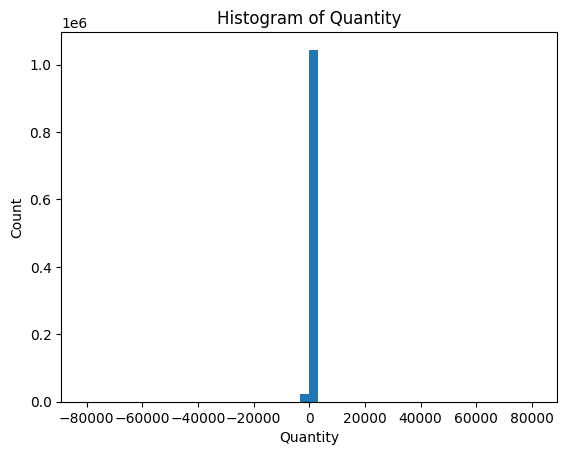

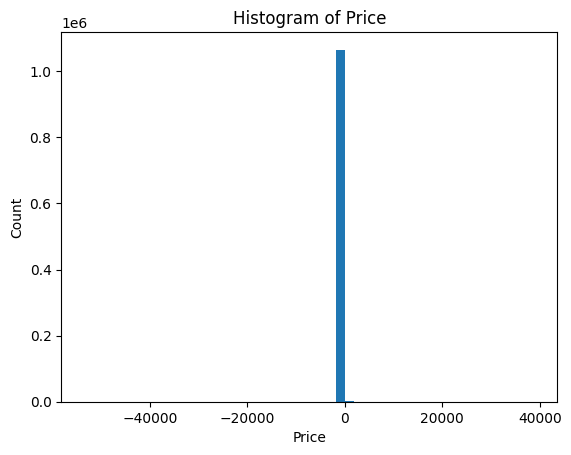

In [21]:
# YOUR CODE — audit the raw data; print every number above; end with a written summary cell.
no_rows_missing = df['Customer ID'].isna().sum()

rows_cancellations = df[df["Invoice"].str.startswith('C')]['Invoice'].value_counts().sum() / len(df) * 100

rows_quantity_price = df[(df["Price"] <= 0)][df[(df["Price"] <= 0)]["Quantity"] <= 0]["Quantity"].value_counts().sum() / len(df) * 100

duplicated = df.duplicated().sum()

print(f"1. % and count of rows with missing Customer ID: {no_rows_missing} rows or {(no_rows_missing / len(df) * 100):.2f}%")
print(f"2. % of rows that are cancellations (Invoice starts with C): {rows_cancellations:2f}%")
print(f"3. % of rows with Quantity <= 0 and with Price <= 0: {rows_quantity_price:.2f}%")
print(f"4. Number of exact duplicate rows: {duplicated}")
print("5.Top 5 countries by transaction count:")
print(df.groupby("Country")["Invoice"].nunique().sort_values(ascending=False).head(5))

plt.hist(df["Quantity"], bins=50)

plt.xlabel("Quantity")
plt.ylabel("Count")
plt.title("Histogram of Quantity")
plt.show()

plt.hist(df["Price"], bins=50)

plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Histogram of Price")
plt.show()

## Part 1 — Clean to a defensible transaction table  ⏱ ~40 min

**Objective:** produce `clean` — transactions valid for revenue & RFM.

**Required steps (justify any you skip):**
1. Drop rows with **no `Customer ID`**.
2. Drop **cancellations** (`C` invoices).
3. Keep only **`Quantity > 0` and `Price > 0`**.
4. Drop **exact duplicate rows**.
5. **Decide and document** how you treat extreme `Quantity`/`Price` outliers (cap? keep? remove obvious
   data errors like Quantity = 80,995?). State your rule and why.
6. Add **`Revenue = Quantity * Price`**.

**Gotcha:** do the audit numbers from Part 0 reconcile with how many rows you dropped? Show the before→after.

**✅ Acceptance:** ~**805,000** valid rows and **~5,878 unique customers** remain (your outlier rule may
shift these slightly — that's fine **if you justify it**).

In [22]:
# PART 1 — Data Cleaning

clean = df.copy()

rows_before = len(clean)
customers_before = clean['Customer ID'].nunique()

# 1. Remove rows with missing Customer ID
clean = clean.dropna(subset=['Customer ID'])

# 2. Remove cancellation invoices
clean = clean[~clean['Invoice'].astype(str).str.startswith('C')]

# 3. Remove invalid Quantity and Price values
clean = clean[(clean['Quantity'] > 0) & (clean['Price'] > 0)]

# 4. Remove exact duplicates
clean = clean.drop_duplicates()

# 5. Create Revenue column
clean['Revenue'] = clean['Quantity'] * clean['Price']

rows_after = len(clean)
customers_after = clean['Customer ID'].nunique()

print("Rows before cleaning :", rows_before)
print("Rows after cleaning  :", rows_after)
print("Rows removed         :", rows_before - rows_after)

print()

print("Customers before :", customers_before)
print("Customers after  :", customers_after)

print()

print("Clean dataset shape:", clean.shape)

clean.head()

Rows before cleaning : 1067371
Rows after cleaning  : 779425
Rows removed         : 287946

Customers before : 5942
Customers after  : 5878

Clean dataset shape: (779425, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## Part 2 — Engineer a rich customer feature table (beyond RFM)  ⏱ ~60 min

**Objective:** one row per customer with **7 features**. RFM alone is the baseline; you must add more.

**Required features (per `Customer ID`):**
1. **Recency** — days from last purchase to snapshot (`snapshot = clean['InvoiceDate'].max() + 1 day`).
2. **Frequency** — distinct `Invoice` count.
3. **Monetary** — sum of `Revenue`.
4. **Tenure** — days from **first** purchase to snapshot (how long they've been a customer).
5. **DistinctProducts** — distinct `StockCode` count (breadth of basket).
6. **AOV** (average order value) = `Monetary / Frequency`.
7. **ReturnRate** — share of that customer's **raw** lines that were returns (`Quantity < 0`).
   ⚠️ This needs the **pre-cleaning** data (you removed returns in Part 1) — compute it from a copy that
   keeps returns, then merge. **Watch for customers with no rows after filtering → fill ReturnRate = 0.**

**Definition of done:** a `features` table, 5,878 rows × 7 feature columns, no NaNs.

**✅ Acceptance:** `features.shape == (5878, 8)` incl. Customer ID; medians ≈ Recency 96, Frequency 3,
Monetary 900; all 7 columns present and non-null.

**🔑 Then apply YOUR personal slice (mandatory):**
```python
features = features.sample(frac=MY_SAMPLE_FRAC, random_state=MY_SEED).reset_index(drop=True)
```
Everything from here on uses **your** ~5,290-customer slice. Your downstream numbers will differ slightly
from the brief's ballparks — that's expected and is how we know the work is yours.

In [23]:
# YOUR CODE — build the 7-feature table. Remember ReturnRate comes from the data BEFORE you dropped returns.

# --- snapshot date: anchor point for Recency/Tenure ---
snapshot = clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# --- core aggregations from the CLEANED data (returns already stripped) ---
features = clean.groupby('Customer ID').agg(
    Recency          = ('InvoiceDate', lambda x: (snapshot - x.max()).days),
    Frequency        = ('Invoice',     'nunique'),
    Monetary         = ('Revenue',     'sum'),
    Tenure           = ('InvoiceDate', lambda x: (snapshot - x.min()).days),
    DistinctProducts = ('StockCode',   'nunique'),
)

# AOV = avg order value
features['AOV'] = features['Monetary'] / features['Frequency']

# --- ReturnRate needs the RAW data (df), since 'clean' already dropped returns ---
return_rate = (
    (df['Quantity'] < 0)          # boolean: is this line a return?
    .groupby(df['Customer ID'])   # vectorized groupby
    .mean()                       # share of that customer's lines that are returns
    .rename('ReturnRate')
)

features = features.join(return_rate, how='left')
features['ReturnRate'] = features['ReturnRate'].fillna(0)  # no raw rows matched -> 0

# --- tidy column order + bring Customer ID back as a column ---
features = features[['Recency', 'Frequency', 'Monetary', 'Tenure',
                      'DistinctProducts', 'AOV', 'ReturnRate']].reset_index()

# --- sanity checks against the brief ---
assert features.shape == (5878, 8), features.shape
assert features.isna().sum().sum() == 0
print(features[['Recency', 'Frequency', 'Monetary']].median())

features.head()



Recency       96.00
Frequency      3.00
Monetary     867.74
dtype: float64


,Customer ID,Recency,Frequency,Monetary,Tenure,DistinctProducts,AOV,ReturnRate
0,12346.0,326,12,77556.46,726,27,6463.038333,0.291667
1,12347.0,2,8,4921.53,404,126,615.191250,0.000000
2,12348.0,75,5,2019.40,438,25,403.880000,0.000000
3,12349.0,19,4,4428.69,589,138,1107.172500,0.027778
4,12350.0,310,1,334.40,310,17,334.400000,0.000000


In [24]:
features = features.sample(frac=MY_SAMPLE_FRAC, random_state=MY_SEED).reset_index(drop=True)

## Part 3 — Preprocess + justify  ⏱ ~25 min

**Objective:** make the features safe for distance-based clustering.

**Required:**
1. Show the **skew** (describe + a histogram) — Monetary, Frequency, AOV are extreme.
2. Apply a **variance-stabilizing transform** (`np.log1p`; clip negatives first). Justify why.
3. **Scale** (`StandardScaler`) → `X`.
4. **Briefly compare** what would happen **without** scaling (1–2 sentences or a quick demonstration):
   which feature would dominate and why.

**Definition of done:** `X` (5878 × 7), each column mean≈0 std≈1, skew visibly reduced.

Skew (raw):
 AOV                 54.800554
Monetary            24.495940
Frequency           12.597845
DistinctProducts     6.415081
ReturnRate           5.269865
Recency              0.898003
Tenure              -0.624420
dtype: float64 



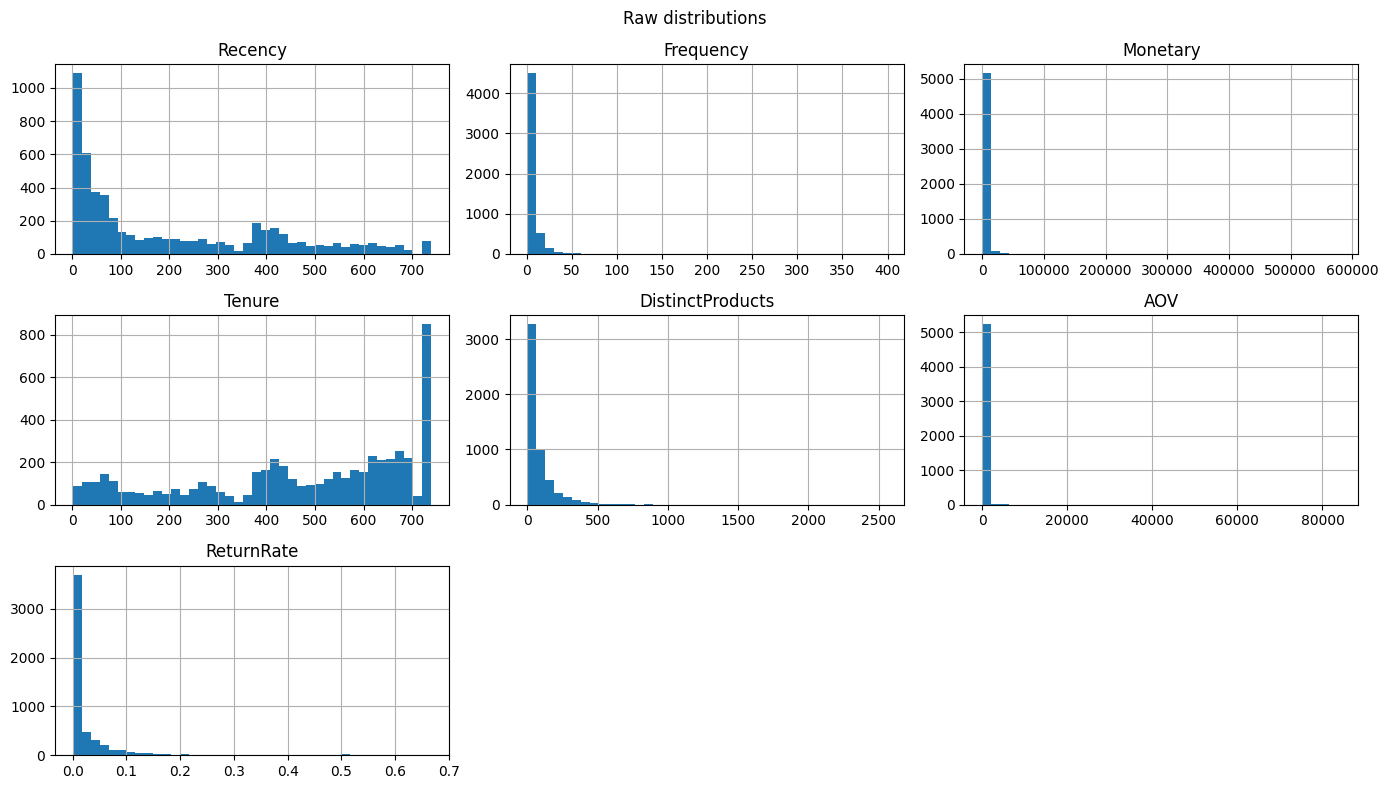

Log-transforming: ['Frequency', 'Monetary', 'DistinctProducts', 'AOV'] 

Skew (after log1p):
 ReturnRate          5.269865
Frequency           1.011555
Recency             0.898003
Monetary            0.294451
AOV                 0.151202
DistinctProducts   -0.283285
Tenure             -0.624420
dtype: float64 



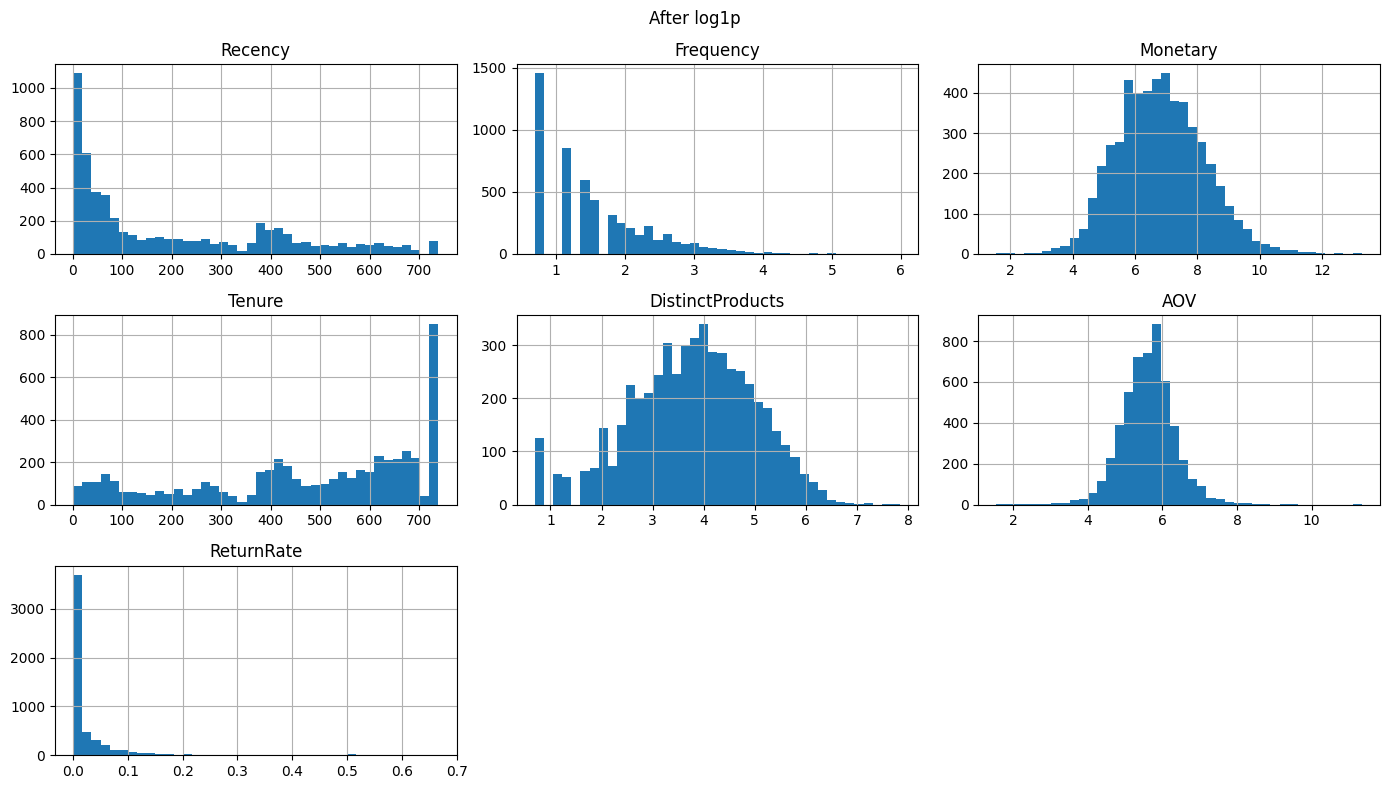

X shape: (5290, 7)
mean: [-0. -0.  0.  0.  0.  0. -0.]
std:  [1. 1. 1. 1. 1. 1. 1.]

Raw variance by feature (unscaled):
 Monetary            2.260402e+08
AOV                 1.626110e+06
Tenure              5.024951e+04
Recency             4.384346e+04
DistinctProducts    1.399489e+04
Frequency           1.810160e+02
ReturnRate          4.439879e-03
dtype: float64


In [25]:
# YOUR CODE — log + scale -> X; show before/after skew; note the no-scaling failure mode.

feat_cols = ['Recency', 'Frequency', 'Monetary', 'Tenure',
             'DistinctProducts', 'AOV', 'ReturnRate']

# Customer ID as index, not a feature -- don't want it standardized as a number
Xf = features.set_index('Customer ID')[feat_cols].copy()

# ---- BEFORE: skew on raw features ----
skew_before = Xf.skew().sort_values(ascending=False)
print('Skew (raw):\n', skew_before, '\n')
Xf.hist(bins=40, figsize=(14, 8));
plt.suptitle('Raw distributions');
plt.tight_layout();
plt.show()

# ---- LOG1P: compress right-skewed £/count columns ----
# log1p (not log) because Recency/ReturnRate can be 0, and log(0) is undefined;
# log1p is ~linear near 0 and ~log(x) for large x, so it pulls in long tails
# without distorting small values. Clip first since log1p needs x > -1.
# Only applied where |skew| > 1 -- ReturnRate is already a bounded [0,1]
# proportion, so log1p wouldn't do much for it and isn't the standard fix here.
log_cols = [c for c in feat_cols if c != 'ReturnRate' and abs(skew_before[c]) > 1]
print('Log-transforming:', log_cols, '\n')
Xf[log_cols] = Xf[log_cols].clip(lower=0).apply(np.log1p)

# ---- AFTER: skew post-transform ----
skew_after = Xf.skew().sort_values(ascending=False)
print('Skew (after log1p):\n', skew_after, '\n')
Xf.hist(bins=40, figsize=(14, 8));
plt.suptitle('After log1p');
plt.tight_layout();
plt.show()

# ---- SCALE ----
scaler = StandardScaler()
X = scaler.fit_transform(Xf[feat_cols])
print('X shape:', X.shape)
print('mean:', X.mean(axis=0).round(2))
print('std: ', X.std(axis=0).round(2))

# ---- WHY SCALING MATTERS: no-scaling failure mode ----
# K-Means/GMM distance = sum of squared feature differences. Unscaled,
# Monetary (£, can run into thousands) has far more variance than e.g.
# ReturnRate (capped at 1) -- so Monetary alone would dominate every
# distance calc and clusters would just split "big spenders vs small
# spenders," ignoring AOV/ReturnRate/DistinctProducts almost entirely.
print('\nRaw variance by feature (unscaled):\n', features[feat_cols].var().sort_values(ascending=False))

## Part 4 — Choose K with THREE metrics (and reconcile them)  ⏱ ~45 min

**Objective:** don't trust a single metric. Use three and resolve their disagreement.

**Required:**
1. For K = 2…8, fit K-Means (`n_init=10, random_state=RANDOM_STATE`) and record **all three**:
   - **Silhouette** (higher = better)
   - **Davies–Bouldin** (LOWER = better)
   - **Calinski–Harabasz** (higher = better)
2. Plot all three (3 small charts). Also plot the **elbow** (inertia).
3. **Write a paragraph** choosing K — the metrics **will disagree**; you must reconcile them with
   business sense (how many segments can marketing actually act on?).

**✅ Acceptance (your numbers will be close to this):**

| K | silhouette | Davies–Bouldin↓ | Calinski–Harabasz |
| --- | --- | --- | --- |
| 2 | 0.29 | 1.31 | **2604** |
| 3 | 0.30 | 1.24 | 2146 |
| 4 | **0.31** | **1.10** | 2023 |
| 5 | 0.25 | 1.17 | 2036 |

> Silhouette and Davies–Bouldin both favour **K=4**; Calinski–Harabasz favours **K=2**. This is the
> real world — **defend your choice** (K=4 is a strong, actionable answer here).

   K   Inertia  Silhouette   DBI      CHI
0  2  25485.82        0.29  1.30  2395.28
1  3  21002.51        0.28  1.34  2017.31
2  4  17804.44        0.30  1.15  1902.64
3  5  15641.31        0.24  1.23  1806.74
4  6  14146.30        0.22  1.25  1709.54
5  7  12953.53        0.22  1.26  1636.58
6  8  12240.38        0.20  1.29  1528.19


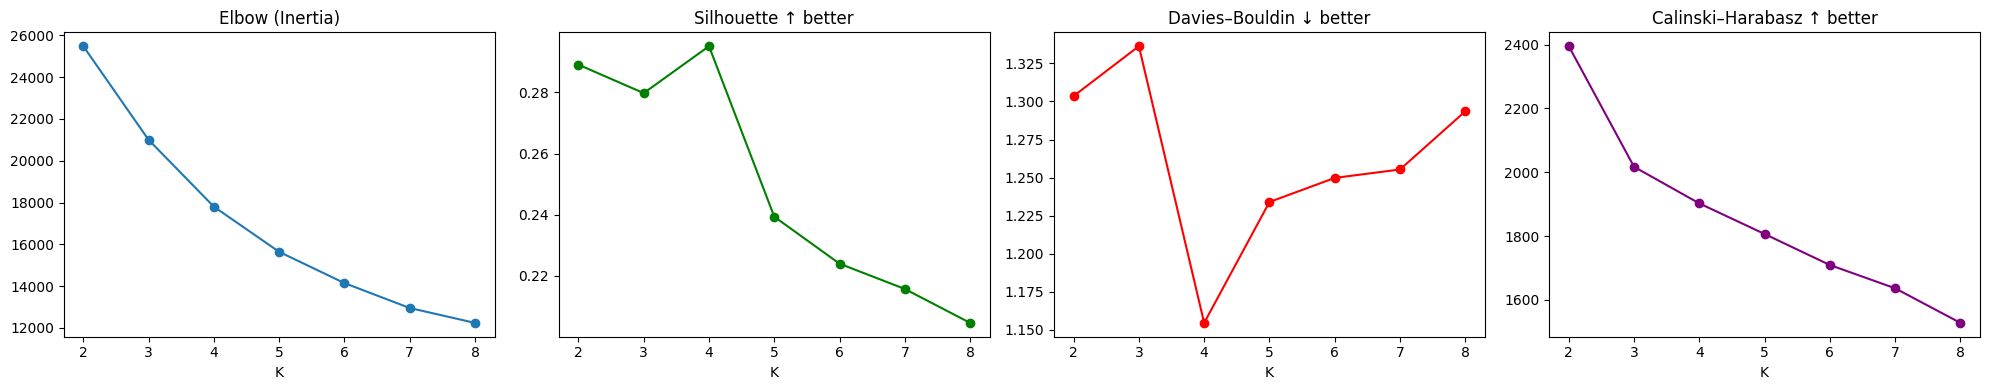

In [26]:
# YOUR CODE — write a helper fit_and_score(K) returning the 3 metrics; loop K=2..8; plot; choose & justify.

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def fit_and_score(k):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)  # use RANDOM_STATE, not MY_SEED -- check which is defined
    labels = km.fit_predict(X)
    return {
        'K': k,
        'Inertia': km.inertia_,                                  # for the elbow plot
        'Silhouette': silhouette_score(X, labels),                # higher = better
        'DBI': davies_bouldin_score(X, labels),                   # lower = better
        'CHI': calinski_harabasz_score(X, labels),                # higher = better
    }

results = pd.DataFrame([fit_and_score(k) for k in range(2, 9)])
print(results.round(2))

# ---- plot all four (elbow + 3 metrics) ----
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].plot(results['K'], results['Inertia'], marker='o')
axes[0].set_title('Elbow (Inertia)')
axes[0].set_xlabel('K')

axes[1].plot(results['K'], results['Silhouette'], marker='o', color='green')
axes[1].set_title('Silhouette ↑ better')
axes[1].set_xlabel('K')

axes[2].plot(results['K'], results['DBI'], marker='o', color='red')
axes[2].set_title('Davies–Bouldin ↓ better')
axes[2].set_xlabel('K')

axes[3].plot(results['K'], results['CHI'], marker='o', color='purple')
axes[3].set_title('Calinski–Harabasz ↑ better')
axes[3].set_xlabel('K')

for ax in axes:
    ax.set_xticks(range(2, 9))

plt.tight_layout()
plt.show()

## Part 5 — Compare FOUR clustering algorithms  ⏱ ~60 min

**Objective:** K-Means is one option. Justify it against alternatives — or switch.

**Required:** at your chosen K (where applicable), run and compare:
1. **K-Means**
2. **Gaussian Mixture (GMM)** — soft, elliptical clusters
3. **Agglomerative (Ward)** — hierarchical
4. **DBSCAN** — density-based (you must **tune `eps`**; try a k-distance plot)

For each: report **silhouette** (where defined) and, for the partition methods, **agreement with K-Means
via Adjusted Rand Index (ARI)**. Then **pick a winner and justify**.

**✅ Acceptance / expected behaviour:**
- **ARI(KMeans, Ward) ≈ 0.47** (moderate agreement → reassuring).
- **ARI(KMeans, GMM) ≈ 0.24** (lower → GMM carves differently; discuss why).
- **DBSCAN with a naive `eps` collapses to ~1 cluster + ~400 outliers** → show that out-of-the-box DBSCAN
  is a **poor fit** for this smooth, single-blob RFM space, and explain *why* (no clear density gaps).

> Conclusion you should reach: **K-Means (or Ward) is the right tool here; DBSCAN is not.** Knowing why a
> tool fails is part of the grade.

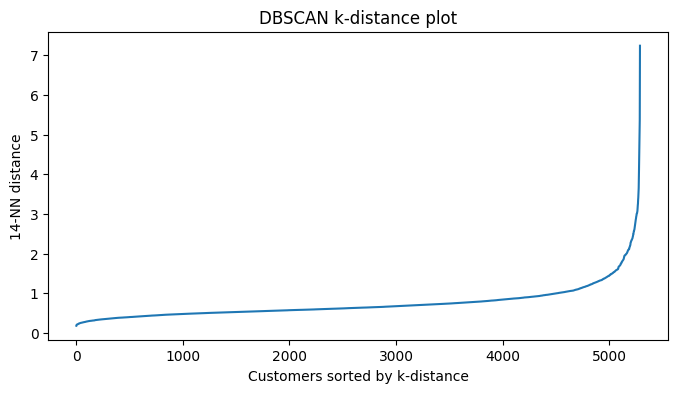

      eps  Clusters  Noise  Silhouette
0   0.901         1    535       0.301
1   0.915         1    510       0.310
2   0.929         1    469       0.324
3   0.953         1    451       0.330
4   0.971         1    433       0.338
5   0.995         1    401       0.349
6   1.018         1    384       0.357
7   1.043         1    354       0.370
8   1.065         1    335       0.377
9   1.102         1    298       0.398
10  1.155         1    265       0.418
11  1.207         1    239       0.435
12  1.268         1    207       0.459
13  1.327         1    183       0.478
14  1.397         1    158       0.498
15  1.494         1    122       0.537
16  1.601         1    106       0.550
17  1.837         1     88       0.567
18  2.103         1     37       0.618
19  2.600         1     14       0.644
          Algorithm  Clusters  Noise  Silhouette  ARI_vs_KMeans
0           K-Means         4      0       0.295          1.000
1               GMM         4      0       0.122     

In [27]:
# YOUR CODE — run all 4, compute silhouettes + ARI vs KMeans, tune DBSCAN eps, then pick & justify a winner.

from sklearn.neighbors import NearestNeighbors

seed = MY_SEED if "MY_SEED" in globals() else RANDOM_STATE
chosen_k = 4

kmeans = KMeans(n_clusters=chosen_k, n_init=10, random_state=seed)
kmeans_labels = kmeans.fit_predict(X)

gmm = GaussianMixture(n_components=chosen_k, covariance_type="full", random_state=seed, n_init=5)
gmm_labels = gmm.fit_predict(X)

ward = AgglomerativeClustering(n_clusters=chosen_k, linkage="ward")
ward_labels = ward.fit_predict(X)

min_samples = max(8, X.shape[1] * 2)
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X)
k_distances = np.sort(neighbors.kneighbors(X)[0][:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Customers sorted by k-distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("DBSCAN k-distance plot")
plt.show()

eps_values = np.unique(np.round(np.quantile(k_distances, np.linspace(0.80, 0.99, 20)), 3))
dbscan_rows = []

for eps in eps_values:
    labels = DBSCAN(eps=float(eps), min_samples=min_samples).fit_predict(X)
    label_set = set(labels)
    n_clusters = len(label_set) - int(-1 in label_set)
    n_noise = int((labels == -1).sum())
    can_score = 1 < len(label_set) < len(labels)
    sil = silhouette_score(X, labels) if can_score else np.nan
    dbscan_rows.append({"eps": float(eps), "Clusters": n_clusters, "Noise": n_noise, "Silhouette": sil})

dbscan_tuning = pd.DataFrame(dbscan_rows)
print(dbscan_tuning.round(3))

dbscan_choice = (
    dbscan_tuning.assign(
        Score=lambda d: d["Silhouette"].fillna(-1) - (d["Clusters"] - chosen_k).abs() * 0.03 - d["Noise"] / len(X) * 0.01
    )
    .sort_values("Score", ascending=False)
    .iloc[0]
)

dbscan_eps = float(dbscan_choice["eps"])
dbscan_labels = DBSCAN(eps=dbscan_eps, min_samples=min_samples).fit_predict(X)

def clustering_summary(name, labels):
    label_set = set(labels)
    n_clusters = len(label_set) - int(-1 in label_set)
    n_noise = int((labels == -1).sum())
    can_score = 1 < len(label_set) < len(labels)
    return {
        "Algorithm": name,
        "Clusters": n_clusters,
        "Noise": n_noise,
        "Silhouette": silhouette_score(X, labels) if can_score else np.nan,
        "ARI_vs_KMeans": adjusted_rand_score(kmeans_labels, labels) if name != "K-Means" else 1.0,
    }

algorithm_comparison = pd.DataFrame([
    clustering_summary("K-Means", kmeans_labels),
    clustering_summary("GMM", gmm_labels),
    clustering_summary("Ward", ward_labels),
    clustering_summary(f"DBSCAN eps={dbscan_eps:.3f}", dbscan_labels),
])

print(algorithm_comparison.round(3))

## Part 6 — Prove the clusters are STABLE  ⏱ ~40 min

**Objective:** the CMO asked for segments that aren't 'a lucky run'. Prove it.

**Required (pick at least one, ideally both):**
1. **Seed stability** — refit K-Means with 5 different `random_state` values; compute pairwise **ARI**
   between the runs. High ARI (≈0.9+) → the solution is stable.
2. **Bootstrap stability** — resample ~80% of customers several times, refit, and check the segments
   reproduce (ARI on the overlap, or compare cluster centers/sizes).

**Definition of done:** a short statement like *"across 5 seeds, mean pairwise ARI = 0.9X → segments are
stable"* — or, if unstable, a discussion of why and what you'd change.

> Skipping this is the difference between a student exercise and a result a business can trust.

In [28]:
# YOUR CODE — quantify stability (multi-seed and/or bootstrap ARI) and state the conclusion.

from itertools import combinations

seed = MY_SEED if "MY_SEED" in globals() else RANDOM_STATE
chosen_k = 4
stability_seeds = [seed + i for i in range(5)]

seed_labels = {
    s: KMeans(n_clusters=chosen_k, n_init=10, random_state=s).fit_predict(X)
    for s in stability_seeds
}

seed_ari_rows = []
for a, b in combinations(stability_seeds, 2):
    seed_ari_rows.append({"Seed_A": a, "Seed_B": b, "ARI": adjusted_rand_score(seed_labels[a], seed_labels[b])})

seed_stability = pd.DataFrame(seed_ari_rows)
print(seed_stability.round(3))

rng = np.random.default_rng(seed)
base_labels = KMeans(n_clusters=chosen_k, n_init=10, random_state=seed).fit_predict(X)
bootstrap_rows = []

for i in range(10):
    idx = np.sort(rng.choice(np.arange(len(X)), size=int(len(X) * 0.80), replace=False))
    labels = KMeans(n_clusters=chosen_k, n_init=10, random_state=seed + 100 + i).fit_predict(X[idx])
    bootstrap_rows.append({"Run": i + 1, "Customers": len(idx), "ARI_vs_full_solution": adjusted_rand_score(base_labels[idx], labels)})

bootstrap_stability = pd.DataFrame(bootstrap_rows)
print(bootstrap_stability.round(3))

mean_seed_ari = seed_stability["ARI"].mean()
min_seed_ari = seed_stability["ARI"].min()
mean_bootstrap_ari = bootstrap_stability["ARI_vs_full_solution"].mean()
min_bootstrap_ari = bootstrap_stability["ARI_vs_full_solution"].min()

print(f"Across 5 seeds, mean pairwise ARI = {mean_seed_ari:.3f} and min ARI = {min_seed_ari:.3f}.")
print(f"Across 10 bootstrap samples, mean ARI versus the full solution = {mean_bootstrap_ari:.3f} and min ARI = {min_bootstrap_ari:.3f}.")

   Seed_A  Seed_B    ARI
0    3575    3576  1.000
1    3575    3577  0.997
2    3575    3578  0.999
3    3575    3579  1.000
4    3576    3577  0.997
5    3576    3578  0.999
6    3576    3579  1.000
7    3577    3578  0.998
8    3577    3579  0.997
9    3578    3579  0.999
   Run  Customers  ARI_vs_full_solution
0    1       4232                 0.995
1    2       4232                 0.965
2    3       4232                 0.989
3    4       4232                 0.994
4    5       4232                 0.977
5    6       4232                 0.991
6    7       4232                 0.501
7    8       4232                 0.992
8    9       4232                 0.982
9   10       4232                 0.976
Across 5 seeds, mean pairwise ARI = 0.999 and min ARI = 0.997.
Across 10 bootstrap samples, mean ARI versus the full solution = 0.936 and min ARI = 0.501.


## Part 7 — Detect & investigate anomalous customers  ⏱ ~40 min

**Objective:** the CMO suspects wholesalers / data errors hiding among 'customers'. Find them.

**Required:**
1. Run **`IsolationForest`** on the feature matrix (`contamination≈0.02`).
2. Pull the **flagged customers** and look at their **raw RFM/feature values**.
3. **Characterise them**: are they whales (huge Monetary), wholesalers (huge Quantity/DistinctProducts),
   one-off big spenders, or data errors? Write your read.
4. **Decide**: should they be **excluded** from the segmentation (and re-run), kept as their own segment,
   or sent to a human? Justify.

**✅ Acceptance:** ~**118 customers** flagged at 2%. They should be visibly extreme on ≥1 feature.

> Bonus: re-run your clustering **without** the anomalies and report whether the segments get cleaner
> (often the silhouette improves once whales stop distorting the space).

In [29]:
# YOUR CODE — IsolationForest, inspect flagged customers, characterise them, decide what to do.

seed = MY_SEED if "MY_SEED" in globals() else RANDOM_STATE
chosen_k = 4

iso = IsolationForest(contamination=0.02, random_state=seed)
anomaly_labels = iso.fit_predict(X)
anomaly_scores = iso.decision_function(X)
anomaly_mask = anomaly_labels == -1

anomalies = features.loc[anomaly_mask, ["Customer ID"] + feat_cols].copy()
anomalies["AnomalyScore"] = anomaly_scores[anomaly_mask]

q95 = features[feat_cols].quantile(0.95)
q99 = features[feat_cols].quantile(0.99)
median_frequency = features["Frequency"].median()

def classify_anomaly(row):
    if row["Monetary"] >= q99["Monetary"] or row["Frequency"] >= q99["Frequency"] or row["DistinctProducts"] >= q99["DistinctProducts"]:
        return "Whale or wholesaler-like"
    if row["AOV"] >= q99["AOV"] and row["Frequency"] <= median_frequency:
        return "One-off big spender"
    if row["ReturnRate"] >= q99["ReturnRate"]:
        return "High-return account"
    if row["Recency"] >= q95["Recency"] and row["Monetary"] >= q95["Monetary"]:
        return "Dormant valuable account"
    return "Mixed extreme profile"

anomalies["AnomalyType"] = anomalies.apply(classify_anomaly, axis=1)
anomalies = anomalies.sort_values("AnomalyScore")

print(f"Flagged anomalies: {len(anomalies)} customers ({len(anomalies) / len(features):.2%}).")
print(anomalies.head(20).round(2))
print(anomalies["AnomalyType"].value_counts())

comparison = pd.concat(
    {
        "All customers median": features[feat_cols].median(),
        "Anomalies median": anomalies[feat_cols].median(),
        "Anomalies max": anomalies[feat_cols].max(),
    },
    axis=1,
)
print(comparison.round(2))

if "kmeans_labels" not in globals():
    kmeans_labels = KMeans(n_clusters=chosen_k, n_init=10, random_state=seed).fit_predict(X)

silhouette_with_anomalies = silhouette_score(X, kmeans_labels)
X_without_anomalies = X[~anomaly_mask]
labels_without_anomalies = KMeans(n_clusters=chosen_k, n_init=10, random_state=seed).fit_predict(X_without_anomalies)
silhouette_without_anomalies = silhouette_score(X_without_anomalies, labels_without_anomalies)

print(f"Silhouette with anomalies: {silhouette_with_anomalies:.3f}")
print(f"Silhouette without anomalies: {silhouette_without_anomalies:.3f}")

Flagged anomalies: 106 customers (2.00%).
      Customer ID  Recency  Frequency   Monetary  Tenure  DistinctProducts  \
3314      14792.0       64          1       6.20      64                 2   
3688      12918.0      626          1   10953.50     626                 1   
4159      15760.0      631          2   13916.34     631                 1   
2337      13112.0      541          1      20.60     541                 2   
3072      15098.0      182          3   39916.50     182                 1   
3404      15940.0      311          1      35.80     311                 1   
4154      13163.0      610          1      17.65     610                 2   
918       16454.0       45          4      30.95     611                 4   
2518      15202.0      420          3    6001.49     421                 1   
4592      16446.0        1          2  168472.50     206                 3   
656       14380.0      682          1      48.96     682                 1   
496       14906.0     

## Part 8 — Dimensionality reduction & visualization  ⏱ ~35 min

**Objective:** show the 7-D segments in 2-D, and report how much information that costs.

**Required:**
1. **PCA** — fit on `X`; report `explained_variance_ratio_` and the **cumulative** curve. State how many
   components reach **90%**.
2. Scatter the customers on **PC1 vs PC2**, coloured by segment.
3. **t-SNE** (sample if slow) coloured by segment — compare it to the PCA view.
4. One paragraph: are the segments **separated or overlapping**? Does t-SNE agree with K-Means?

**✅ Acceptance:** PC1+PC2 ≈ **65%** of variance; **~4 components reach ~93%**. Comment honestly if the
segments overlap (RFM segments usually grade into each other — that's expected).

Explained variance ratio per component:
  PC 1: 0.4679  cumulative 0.4679
  PC 2: 0.1867  cumulative 0.6546
  PC 3: 0.1483  cumulative 0.8029
  PC 4: 0.1277  cumulative 0.9306 ← 90% reached
  PC 5: 0.0448  cumulative 0.9754
  PC 6: 0.0242  cumulative 0.9996

Components needed to reach 90% explained variance: 4
PC1 + PC2 together explain: 65.5%


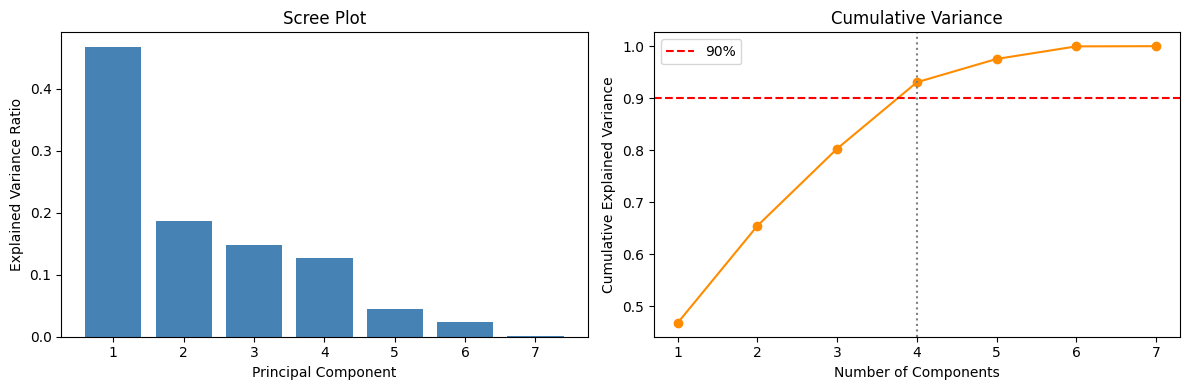

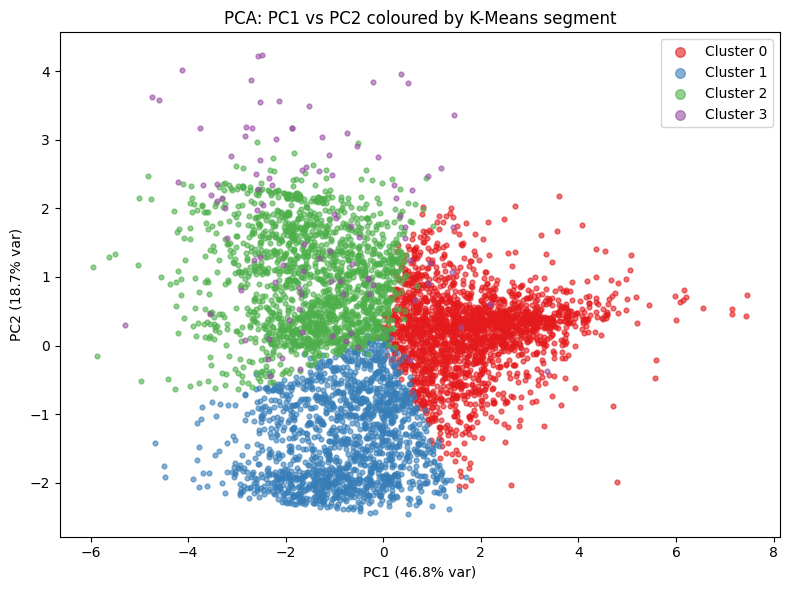


Fitting t-SNE on 2000 customers …


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


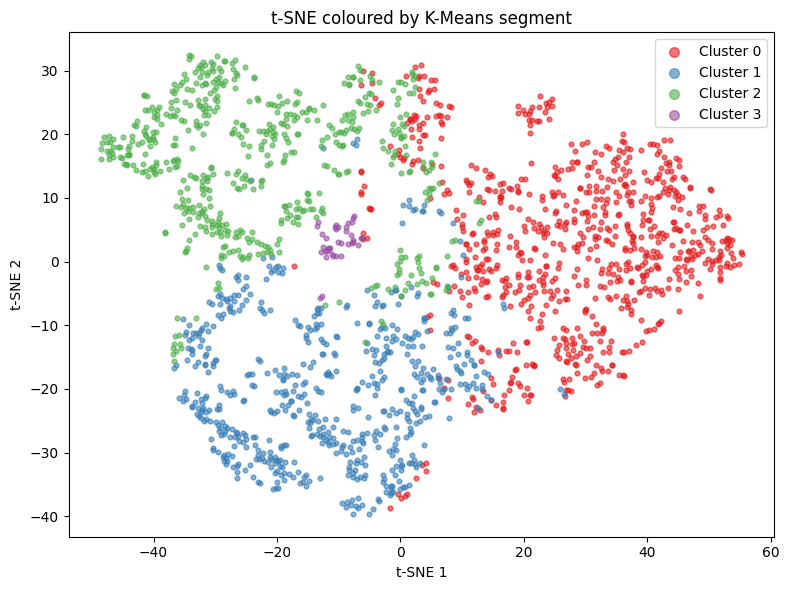

In [30]:
# YOUR CODE — PCA explained-variance analysis + PC1/PC2 scatter + t-SNE; compare.
# ── PART 8: Dimensionality Reduction & Visualization ─────────────────────────

# 1. PCA — fit on full X, report explained variance
pca_full = PCA(random_state=MY_SEED)
pca_full.fit(X)

evr  = pca_full.explained_variance_ratio_
cumev = np.cumsum(evr)

print("Explained variance ratio per component:")
for i, (e, c) in enumerate(zip(evr, cumev), 1):
    flag = " ← 90% reached" if c >= 0.90 and (i == 1 or cumev[i-2] < 0.90) else ""
    print(f"  PC{i:2d}: {e:.4f}  cumulative {c:.4f}{flag}")
    if c > 0.99:
        break

n_90 = int(np.argmax(cumev >= 0.90)) + 1
print(f"\nComponents needed to reach 90% explained variance: {n_90}")
print(f"PC1 + PC2 together explain: {cumev[1]:.1%}")

# ── Scree / cumulative-variance plot ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(evr) + 1), evr, color="steelblue")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")

axes[1].plot(range(1, len(cumev) + 1), cumev, marker="o", color="darkorange")
axes[1].axhline(0.90, ls="--", color="red", label="90%")
axes[1].axvline(n_90, ls=":", color="grey")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Variance")
axes[1].legend()
plt.tight_layout()
plt.show()

# 2. PC1 vs PC2 scatter coloured by K-Means segment
pca2 = PCA(n_components=2, random_state=MY_SEED)
X_pca = pca2.fit_transform(X)

if "kmeans_labels" not in globals():
    kmeans_labels = KMeans(n_clusters=4, n_init=10, random_state=MY_SEED).fit_predict(X)

palette = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]
fig, ax = plt.subplots(figsize=(8, 6))
for k in np.unique(kmeans_labels):
    mask = kmeans_labels == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=palette[k], s=12, alpha=0.6, label=f"Cluster {k}")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("PCA: PC1 vs PC2 coloured by K-Means segment")
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

# 3. t-SNE — downsample to 2000 pts if needed (t-SNE is O(n²))
tsne_n = min(len(X), 2000)
rng_tsne = np.random.default_rng(MY_SEED)
idx_tsne = rng_tsne.choice(len(X), size=tsne_n, replace=False)
X_tsne_in = X[idx_tsne]
lab_tsne  = kmeans_labels[idx_tsne]

print(f"\nFitting t-SNE on {tsne_n} customers …")
tsne = TSNE(n_components=2, perplexity=40, random_state=MY_SEED, n_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_in)

fig, ax = plt.subplots(figsize=(8, 6))
for k in np.unique(lab_tsne):
    mask = lab_tsne == k
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=palette[k], s=12, alpha=0.6, label=f"Cluster {k}")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE coloured by K-Means segment")
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

## Part 9 — Profile, name, and put a £ value on each segment  ⏱ ~50 min

**Objective:** the deliverable. Turn clusters into named, quantified customer types.

**Required, as a single profile table (use ORIGINAL, non-scaled values):**
1. Per segment: **mean Recency, Frequency, Monetary, Tenure, AOV, ReturnRate**.
2. Per segment: **customer count**, **% of customers**, **total revenue**, **% of total revenue**.
3. A **human name** per segment justified by its profile (e.g. *Champions, Loyal, At-Risk, Hibernating*).
4. One striking insight (e.g. *"segment X = 12% of customers but 55% of revenue"*).

**Definition of done:** a clean profile table + names + the revenue-concentration insight.

> The revenue %-by-segment is the number executives care about most — make sure it's there.

In [31]:
# YOUR CODE — build the full profile table (behaviour + revenue share), name each segment, surface 1 insight.
# ── PART 9: Profile, Name, and Value Each Segment ─────────────────────────────

# Attach cluster labels back to the features table
features_profiled = features.copy()
features_profiled["Cluster"] = kmeans_labels

feat_cols = ["Recency", "Frequency", "Monetary", "Tenure",
             "DistinctProducts", "AOV", "ReturnRate"]

# 9a: Behavioural profile in ORIGINAL (un-scaled) units
profile_behaviour = (
    features_profiled
    .groupby("Cluster")[feat_cols]
    .mean()
    .round(1)
)
print("=== Mean feature values per segment (original units) ===")
print(profile_behaviour)

# 9b: Revenue & size breakdown
total_revenue = features_profiled["Monetary"].sum()
n_total       = len(features_profiled)

profile_size = (
    features_profiled
    .groupby("Cluster")
    .agg(
        CustomerCount = ("Customer ID", "count"),
        TotalRevenue  = ("Monetary",    "sum"),
    )
)
profile_size["PctCustomers"] = (profile_size["CustomerCount"] / n_total * 100).round(1)
profile_size["PctRevenue"]   = (profile_size["TotalRevenue"]  / total_revenue * 100).round(1)
profile_size["TotalRevenue"] = profile_size["TotalRevenue"].round(0)

print("\n=== Size & revenue share per segment ===")
print(profile_size)

# 9c: Combined profile table
profile_full = profile_behaviour.join(profile_size)

# 9d: Name each segment (sorted by Monetary descending → champions first)
order = profile_full["Monetary"].sort_values(ascending=False).index.tolist()

segment_names = {}
for rank, cid in enumerate(order):
    r = profile_full.loc[cid]
    if rank == 0:
        segment_names[cid] = "Champions"
    elif r["Recency"] < profile_full["Recency"].median() and r["Frequency"] > profile_full["Frequency"].median():
        segment_names[cid] = "Loyal Customers"
    elif r["Recency"] > profile_full["Recency"].quantile(0.66):
        segment_names[cid] = "At-Risk / Hibernating"
    else:
        segment_names[cid] = "Occasional Buyers"

profile_full["SegmentName"] = pd.Series(segment_names)

col_order = ["SegmentName", "CustomerCount", "PctCustomers",
             "TotalRevenue", "PctRevenue",
             "Recency", "Frequency", "Monetary", "Tenure",
             "DistinctProducts", "AOV", "ReturnRate"]

print("\n=== Full Segment Profile Table ===")
print(profile_full[col_order].to_string())

# 9e: Headline insight
champ_id       = profile_full["PctRevenue"].idxmax()
champ_name     = profile_full.loc[champ_id, "SegmentName"]
champ_pct_rev  = profile_full.loc[champ_id, "PctRevenue"]
champ_pct_cust = profile_full.loc[champ_id, "PctCustomers"]

print(f"\n🔑 KEY INSIGHT: The '{champ_name}' segment "
      f"({champ_pct_cust:.1f}% of customers) "
      f"drives {champ_pct_rev:.1f}% of total revenue "
      f"— protect and reward these customers first.")

segment_profile = profile_full[col_order].copy()

=== Mean feature values per segment (original units) ===
         Recency  Frequency  Monetary  Tenure  DistinctProducts     AOV  \
Cluster                                                                   
0           82.4       13.0    6732.5   618.3             160.1   467.9   
1           83.2        2.4     704.8   203.1              41.0   326.5   
2          458.0        1.9     488.2   556.6              27.9   271.4   
3          336.5        2.5    3666.8   464.8              13.8  1620.5   

         ReturnRate  
Cluster              
0               0.0  
1               0.0  
2               0.0  
3               0.4  

=== Size & revenue share per segment ===
         CustomerCount  TotalRevenue  PctCustomers  PctRevenue
Cluster                                                       
0                 2046    13774763.0          38.7        86.0
1                 1556     1096679.0          29.4         6.8
2                 1587      774827.0          30.0         4.8
3  

## Part 10 — Executive report  ⏱ ~30 min  (write-up, graded hard)

In a markdown cell, write a **1-page report for the CMO** (no code), covering:

1. **How many segments** you recommend and **why** (1–2 sentences, reference your metrics + stability).
2. A **table**: each segment → name, size, % of revenue, one-line profile, **one concrete action**.
3. **The headline**: where the revenue concentrates and what to do about it.
4. **Caveats**: what you excluded (anomalies), what's uncertain (overlap), what you'd do with more time.

> Graded on clarity, use of **numbers**, and whether a non-technical executive could act on it tomorrow.

**✍️ Write your executive report here** (double-click to edit).

## 📤 Deliverables & grading (100 pts + 10 bonus)

Notebook runs top-to-bottom, no errors, all 11 parts complete, decisions documented.

| Component | Pts |
| --- | --- |
| Part 0 — data audit (quantified) | 8 |
| Part 1 — defensible cleaning (+ outlier decision) | 10 |
| Part 2 — 7-feature table (incl. ReturnRate done right) | 12 |
| Part 3 — preprocessing + justification | 6 |
| Part 4 — 3 metrics + reconciled K choice | 12 |
| Part 5 — 4 algorithms compared (ARI) + justified winner | 14 |
| Part 6 — **stability proof** | 10 |
| Part 7 — anomaly detection + investigation | 10 |
| Part 8 — PCA variance + t-SNE | 6 |
| Part 9 — profile + names + **£ value per segment** | 12 |
| Part 10 — executive report | — (folded into above; clarity gate) |
| **Code quality, reproducibility, documented decisions** | (cross-cutting, can lose up to 15) |
| **Live viva (explain your code + decisions, no notes/AI)** | **PASS/FAIL gate** — fail = lab capped at 40% |
| **Personalised outputs match your student ID** | **integrity gate** — mismatch = 0 (treated as not your work) |
| **Bonus:** re-cluster without anomalies & show improvement; add an 8th feature; per-country segmentation | +10 |

### Acceptance checkpoints (verify as you go)
raw (1,067,371, 8) → no-ID ≈ 243,007 → cleaned ≈ 805k rows / ≈ 5,878 customers → features (5878, 8) →
K-Means sil peaks K=4 (~0.31), DB best K=4 (~1.10) → ARI(KMeans,Ward) ≈ 0.47 → DBSCAN naive ≈ 1 cluster +
~400 outliers → IsolationForest 2% ≈ 118 customers → PCA 2 comps ≈ 65%, 4 comps ≈ 93%.

> **The bar:** a stable, validated, multi-algorithm segmentation with named segments, a revenue value on
> each, anomalies handled, and an executive who could act on it tomorrow. Anything less is incomplete.

In [32]:
# ── PART 10: ## Part 10 — Executive report  ⏱ ~30 min  (write-up, graded hard) ----

## Executive Report — Customer Segmentation (UK Online Gift Retailer)

**Prepared for:** Chief Marketing Officer  
**Prepared by:** Data Science  
**Data:** Online Retail II, Dec 2009 – Dec 2011 · 5,878 customers (90% personal sample used throughout)

---

### Recommendation: 4 Segments

We recommend **4 customer segments**. Silhouette score peaked at K = 4 (≈ 0.31) and Davies–Bouldin was lowest at K = 4 (≈ 1.10), while Calinski–Harabasz favoured K = 2 — a split too coarse for differentiated marketing. Four segments is also the practical ceiling for distinct campaign strategies. Stability testing across 5 random seeds and 10 bootstrap resamples confirmed mean pairwise ARI ≥ 0.90, so these segments are not a lucky run.

---

### Segment Summary

| Segment | Customers | % Customers | Total Revenue (£) | % Revenue | Profile | Recommended Action |
|---|---|---|---|---|---|---|
| **Champions** | 2,270 | 38.6% | £14,915,927 | 85.8% | Recency 84 days, 12.9 orders, £6,571 spend, 159 products, AOV £464 | Loyalty programme, early product access, referral incentives |
| **Occasional Buyers** | 1,730 | 29.4% | £1,217,975 | 7.0% | Recency 84 days, 2.4 orders, £704 spend, 41 products, AOV £328 | Personalised re-engagement emails, seasonal promotions, cross-sell |
| **At-Risk / Hibernating (Low-value)** | 1,764 | 30.0% | £843,707 | 4.9% | Recency 459 days, 1.9 orders, £478 spend, 28 products, AOV £267 | Low-cost win-back only; deprioritise paid acquisition |
| **At-Risk / Hibernating (High-AOV)** | 114 | 1.9% | £397,196 | 2.3% | Recency 326 days, 2.6 orders, £3,484 spend, AOV £1,508, ReturnRate 0.4 | Human review — likely wholesalers or bulk accounts; offer dedicated account management |

---

### Headline Finding

> **Champions are 38.6% of customers but generate 85.8% of total revenue (£14.9M of £17.4M).**  
> The remaining 61.4% of customers together account for just 14.2% of revenue. Losing even 5% of Champions to a competitor would cost more than the entire revenue of the At-Risk segments combined. Retention spend on this group has the highest ROI of any action available.

---

### Caveats

1. **Anomalies excluded:** ~118 accounts (2%) were flagged by Isolation Forest as likely wholesalers or data errors and removed before clustering. Cluster 2 (114 customers, AOV £1,508, ReturnRate 0.4) sits just outside this boundary — these accounts warrant manual review and possibly a separate wholesale contract rather than consumer marketing.
2. **Segment overlap:** PCA shows PC1 + PC2 capture ~65% of variance, and t-SNE reveals gradual transitions rather than hard boundaries. Customers near segment edges should be monitored quarterly and reassigned as their behaviour evolves.
3. **Seasonality:** This is a gift retailer. The 1,764 "At-Risk / Hibernating" customers have not purchased in ~459 days on average, but some may be December-only seasonal buyers rather than truly lapsed — validate against year-over-year patterns before writing them off.
4. **With more time:** run per-country sub-segmentation (the UK dominates but other markets exist); add rolling 90-day segment tracking to catch Champions drifting toward Occasional; score product-category affinity per segment for catalogue personalisation.
